# Developing the Models

Notebook 3 explored the training data and permanently separated the test set. This notebook uses the **training data only** to answer five questions:

1. Can the predictors identify participants with untreated cavities better than a simple baseline?
2. Which model performs best across repeated validation folds?
3. Do reasonable hyperparameter changes improve the models?
4. Are the predicted probabilities reasonably calibrated and are the top models meaningfully different?
5. What probability threshold should each model use when it eventually reaches the test set?

The four models are logistic regression, random forest, gradient boosting, and a feed-forward neural network. They are intentionally different: the first is linear and interpretable, while the other three can learn nonlinear patterns and interactions.

No final test-set performance is reported here. Notebook 5 will open the untouched test data for the first time.

## Keeping the Test Set Untouched

The permanent test set represents new participants that the models have never seen. Loading it during model development could influence model choices, even if that influence is accidental.

For that reason, every decision in this notebook, including preprocessing, hyperparameter selection, and probability thresholds—is based only on `training_data.csv`. The code below never reads `test_data.csv`.

## Imports and Setup

This section imports the modeling tools, defines the project folders, and keeps the plotting style consistent with the earlier notebooks.

In [1]:
from pathlib import Path
import hashlib  # hashes training_data.csv so the saved model metadata can prove which data version produced it
import json  # writes that metadata (hyperparameters, data hash, versions) alongside the saved models
import time

import joblib  # persists the fitted pipelines (preprocessing + model) for reuse in later notebooks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

try:
    from IPython.display import display
except ImportError:
    # This fallback is only needed in a plain Python environment. Jupyter uses
    # IPython's richer table and estimator displays.
    def display(value):
        print(value)

from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


# Find the project folder whether the notebook is launched from the repository
# root or from inside the notebooks folder in VS Code.
current_folder = Path.cwd()
project_candidates = [current_folder, current_folder.parent]

for candidate in project_candidates:
    if (candidate / "data" / "processed" / "training_data.csv").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Could not locate data/processed/training_data.csv. "
        "Open this notebook from the project repository."
    )

TRAINING_PATH = PROJECT_ROOT / "data" / "processed" / "training_data.csv"
MODEL_FOLDER = PROJECT_ROOT / "outputs" / "models"
TABLE_FOLDER = PROJECT_ROOT / "outputs" / "tables"

MODEL_FOLDER.mkdir(parents=True, exist_ok=True)
TABLE_FOLDER.mkdir(parents=True, exist_ok=True)


# Reproducibility and plot styling
# RANDOM_STATE is reused everywhere a split or search is randomized (CV folds,
# RandomizedSearchCV, MLPClassifier) so the whole notebook reproduces exactly.
RANDOM_STATE = 42
PURPLE = "#5d32ca"
GREEN = "#82b600"
ORANGE = "#f59e0b"
BLUE = "#2f80ed"
GRAY = "#8a8a8a"

# One fixed color per model keeps every plot in the notebook visually
# consistent, so a model can be recognized by color across sections.
MODEL_COLORS = {
    "Dummy Baseline": GRAY,
    "Logistic Regression": PURPLE,
    "Random Forest": GREEN,
    "Gradient Boosting": ORANGE,
    "Neural Network": BLUE,
}

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

print(f"Project folder: {PROJECT_ROOT}")
print(f"scikit-learn version: {sklearn.__version__}")


Project folder: /Users/vedantpatil/Desktop/Dental Caries Prediction Project
scikit-learn version: 1.8.0


## Loading and Checking the Training Data

Before defining any model, this section confirms that the training file still has the expected cohort size, target distribution, identifiers, and missing-value pattern created in Notebook 3.

In [2]:
# Load only the training portion created in Notebook 3.
training_data = pd.read_csv(TRAINING_PATH)


# These checks stop the notebook immediately if the modeling file has changed
# in a way that could make the later results unreliable.
assert training_data["SEQN"].is_unique, "SEQN should uniquely identify each participant."
assert set(training_data["has_cavity"].unique()) == {0, 1}, "The target must contain only 0 and 1."
assert training_data.drop(columns="income_poverty_ratio").isna().sum().sum() == 0
assert (
    training_data["income_poverty_ratio"].isna().astype(int)
    == training_data["income_poverty_ratio_missing"]
).all(), "The missing-income flag must match the missing income values."


data_check = pd.DataFrame(
    {
        "Check": [
            "Training participants",
            "Columns",
            "Untreated-cavity cases",
            "Cavity prevalence",
            "Duplicate SEQN values",
            "Missing income values",
            "Other missing values",
        ],
        "Result": [
            f"{len(training_data):,}",
            f"{training_data.shape[1]:,}",
            f"{training_data['has_cavity'].sum():,}",
            f"{training_data['has_cavity'].mean():.1%}",
            f"{training_data['SEQN'].duplicated().sum():,}",
            f"{training_data['income_poverty_ratio'].isna().sum():,}",
            f"{training_data.drop(columns='income_poverty_ratio').isna().sum().sum():,}",
        ],
    }
)

data_check

,Check,Result
0,Training participants,"10,572"
1,Columns,15
2,Untreated-cavity cases,"1,936"
3,Cavity prevalence,18.3%
4,Duplicate SEQN values,0
5,Missing income values,"1,349"
6,Other missing values,0


The checks confirm that the notebook is using the 10,572-person training set. About 18% of participants have at least one untreated cavity, so the target is imbalanced but not extremely rare.

Income remains the only predictor with missing values. Its value will be imputed *inside* each cross-validation fold instead of being filled once using the complete training dataset.

## Survey Design and the Scope of This Project

NHANES does not survey a simple random sample of the U.S. population. It samples in stages, first picking regions, then households within those regions, then people within households, and it deliberately over-samples some groups. Because of this, turning NHANES data into an accurate national estimate normally requires correction factors: an examination weight (`WTMECPRP`) plus strata and primary-sampling-unit (PSU) variables that describe how the sampling was done.

This project has a narrower goal than estimating national prevalence: predicting whether an individual participant has untreated cavities, based on that participant's own characteristics. Because of that, the survey weights are deliberately left out of model training. One consequence is that the 18.3% cavity rate reported here describes only this training cohort, not the entire U.S. population.

Correcting for the sampling weights would also normally account for PSU clustering, since people sampled from the same area tend to be more alike than two random people from the whole country. The training/test split in this project does not do that correction. That is a reasonable simplification for predicting individual outcomes, but it means the results should not be read as population-level estimates.


## Defining the Target and Predictors

`has_cavity` is the outcome the models will learn to predict. `SEQN` is removed because it is only an NHANES participant identifier; allowing a model to use it would add a meaningless number that will not generalize to future participants.

The remaining 13 columns are the predictors. Self-rated teeth condition is included because it is a legitimate questionnaire response, but Notebook 6 will also test how the models behave without this especially direct predictor.

In [3]:
# Predictors that have a numeric order and benefit from scaling in the
# logistic-regression and neural-network pipelines.
scaled_features = [
    "age",
    "income_poverty_ratio",
    "dental_visit_recency_ord",
    "teeth_condition_ord",
]


# These columns are already 0/1 indicators, so their original scale is useful.
binary_features = [
    "sex_female",
    "diabetes_yes",
    "diabetes_borderline",
    "race_mexican_american",
    "race_other_hispanic",
    "race_non-hispanic_black",
    "race_non-hispanic_asian",
    "race_other_multi",
    "income_poverty_ratio_missing",
]

feature_columns = scaled_features + binary_features

X = training_data[feature_columns].copy()
y = training_data["has_cavity"].copy()


feature_summary = pd.DataFrame(
    {
        "Feature": feature_columns,
        "Modeling role": [
            "Age in years",
            "Income-to-poverty ratio",
            "Ordered dental-visit recency",
            "Ordered self-rated teeth condition",
            "1 = female; 0 = male",
            "1 = diagnosed diabetes",
            "1 = borderline diabetes",
            "1 = Mexican American",
            "1 = other Hispanic",
            "1 = non-Hispanic Black",
            "1 = non-Hispanic Asian",
            "1 = other or multiracial",
            "1 = income value was missing",
        ],
    }
)

print(f"Predictor matrix: {X.shape[0]:,} rows x {X.shape[1]} predictors")
print(f"Target prevalence: {y.mean():.1%}")
feature_summary

Predictor matrix: 10,572 rows x 13 predictors
Target prevalence: 18.3%


,Feature,Modeling role
0,age,Age in years
1,income_poverty_ratio,Income-to-poverty ratio
2,dental_visit_recency_ord,Ordered dental-visit recency
3,teeth_condition_ord,Ordered self-rated teeth condition
4,sex_female,1 = female; 0 = male
5,diabetes_yes,1 = diagnosed diabetes
6,diabetes_borderline,1 = borderline diabetes
7,race_mexican_american,1 = Mexican American
8,race_other_hispanic,1 = other Hispanic
9,race_non-hispanic_black,1 = non-Hispanic Black


The indicator columns use reference categories:

- `sex_female = 0` represents male participants.
- `diabetes_yes = 0` and `diabetes_borderline = 0` together represent no diabetes.
- When every race indicator equals 0, the participant is in the non-Hispanic White reference group.

Reference categories prevent redundant columns while still allowing the models to compare every represented group.

## Building the Preprocessing Pipelines

Preprocessing must be learned only from the rows available to a model during a particular fold. A scikit-learn `Pipeline` keeps the preprocessing and model together, so the validation fold cannot influence the income median or scaling values.

Two preprocessing approaches are used:

- **Logistic regression and neural network:** impute the ordered numeric features, standardize them, and leave the binary indicators as 0/1.
- **Random forest and gradient boosting:** impute missing values but do not standardize, because tree splits are unaffected by measurement scale.

In [4]:
# The first pipeline handles variables whose numerical scale matters.
scaled_feature_pipeline = Pipeline(
    steps=[
        # Only income is currently missing, but placing the imputer here ensures
        # the median is learned separately within each training fold.
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("scaled", scaled_feature_pipeline, scaled_features),
        ("binary", "passthrough", binary_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)


# Every tree predictor is already numeric. Tree models only need the
# fold-specific missing-value replacement and do not need standardization.
tree_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

print("Linear/neural preprocessing:")
display(linear_preprocessor)

print("Tree preprocessing:")
display(tree_preprocessor)

Linear/neural preprocessing:


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaled', ...), ('binary', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. 

Tree preprocessing:


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomiss

## Setting Up Cross-Validation

Five-fold stratified cross-validation divides the training data into five parts. Each model trains on four folds and validates on the remaining fold, repeating until every fold has served as validation data once.

`StratifiedKFold` keeps cavity prevalence similar across the folds. Shuffling and the fixed random seed make the split reproducible.

In [5]:
cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)


# Show the validation portion of each fold so the class balance can be checked.
fold_rows = []

for fold_number, (_, validation_indices) in enumerate(
    cross_validation.split(X, y),
    start=1,
):
    validation_target = y.iloc[validation_indices]
    fold_rows.append(
        {
            "Fold": fold_number,
            "Validation participants": len(validation_target),
            "Cavity cases": int(validation_target.sum()),
            "Cavity prevalence": validation_target.mean(),
        }
    )

fold_summary = pd.DataFrame(fold_rows)
fold_summary.assign(
    **{"Cavity prevalence": fold_summary["Cavity prevalence"].map("{:.1%}".format)}
)

,Fold,Validation participants,Cavity cases,Cavity prevalence
0,1,2115,387,18.3%
1,2,2115,388,18.3%
2,3,2114,387,18.3%
3,4,2114,387,18.3%
4,5,2114,387,18.3%


## Choosing the Evaluation Metrics

No single metric answers every modeling question:

- **PR-AUC (average precision)** is the primary selection metric. It focuses on the positive cavity class and is especially useful when one class is less common.
- **ROC-AUC** measures how well predicted probabilities rank cavity cases above non-cavity cases across thresholds.
- **Recall** is the share of actual cavity cases detected.
- **Precision** is the share of predicted cavity cases that are correct.
- **F1 score** balances precision and recall.
- **Balanced accuracy** averages performance on the cavity and non-cavity classes.
- **Accuracy** is included for context but can look high simply because most participants do not have cavities.

PR-AUC and ROC-AUC evaluate probability ranking. The other metrics initially use the standard probability threshold of 0.50.

In [6]:
# zero_division=0 prevents undefined precision warnings when a simple baseline
# predicts no positive cases.
scoring = {
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
    "recall": make_scorer(recall_score, zero_division=0),
    "precision": make_scorer(precision_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "balanced_accuracy": "balanced_accuracy",
    "accuracy": "accuracy",
}


# Turns cross_validate's per-fold arrays into one row of fold means/stds.
def summarize_cross_validation(model_name, results):
    """Convert one cross-validation result into a readable one-row table."""
    row = {"Model": model_name}

    for metric_name in scoring:
        scores = results[f"test_{metric_name}"]
        row[f"{metric_name}_mean"] = scores.mean()
        row[f"{metric_name}_std"] = scores.std(ddof=1)

    row["fit_time_seconds"] = results["fit_time"].mean()
    return row


# Rounds values only for display, so later calculations keep full precision.
def formatted_model_table(frame):
    """Apply consistent display formatting without changing stored values."""
    display_frame = frame.copy()
    metric_columns = [
        column
        for column in display_frame.columns
        if column.endswith("_mean") or column.endswith("_std")
    ]

    display_frame[metric_columns] = display_frame[metric_columns].round(3)
    display_frame["fit_time_seconds"] = display_frame["fit_time_seconds"].round(2)
    return display_frame


## Establishing a Dummy Baseline

The dummy model does not learn relationships between predictors and cavities. It always uses the training-fold class distribution, which gives the real models a minimum benchmark to beat.

For this dataset, a useful model should achieve PR-AUC above the cavity prevalence of about 0.18 and ROC-AUC above random ranking at 0.50.

In [7]:
# A pipeline that always predicts the majority class, ignoring the predictors.
dummy_model = Pipeline(
    steps=[
        ("preprocessor", clone(tree_preprocessor)),
        ("model", DummyClassifier(strategy="prior")),
    ]
)

# Score the dummy across the same 5 folds used for every other model.
dummy_results = cross_validate(
    dummy_model,
    X,
    y,
    cv=cross_validation,
    scoring=scoring,
    n_jobs=-1,
    error_score="raise",
)

# Collapse the 5 fold scores into one summary row.
dummy_summary = pd.DataFrame(
    [summarize_cross_validation("Dummy Baseline", dummy_results)]
)

# Display the baseline that every real model needs to beat.
formatted_model_table(dummy_summary)


,Model,average_precision_mean,average_precision_std,roc_auc_mean,roc_auc_std,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std,balanced_accuracy_mean,balanced_accuracy_std,accuracy_mean,accuracy_std,fit_time_seconds
0,Dummy Baseline,0.183,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.817,0.0,0.02


## Defining the Four Initial Models

Each model approaches the same prediction problem differently:

- **Logistic regression** estimates one linear relationship between the predictors and cavity probability. It provides a strong, interpretable benchmark.
- **Random forest** averages many decision trees. It can identify nonlinear relationships and interactions without relying on one tree.
- **Gradient boosting** builds trees sequentially, with each tree focusing on errors left by the previous trees.
- **Neural network** passes the predictors through hidden layers of connected units. It can learn flexible nonlinear patterns, but scaling and protection against overfitting are especially important.

The neural network uses early stopping: part of each training fold is held aside internally, and training stops when that internal validation score stops improving. This does not use the permanent test set.

In [8]:
# Reasonable starting settings for each model, not yet tuned.
initial_models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("preprocessor", clone(linear_preprocessor)),
            (
                "model",
                LogisticRegression(
                    C=1.0,
                    class_weight=None,
                    max_iter=2_000,
                    solver="liblinear",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", clone(tree_preprocessor)),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=300,
                    n_jobs=1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Gradient Boosting": Pipeline(
        steps=[
            ("preprocessor", clone(tree_preprocessor)),
            (
                "model",
                GradientBoostingClassifier(
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Neural Network": Pipeline(
        steps=[
            ("preprocessor", clone(linear_preprocessor)),
            (
                "model",
                MLPClassifier(
                    hidden_layer_sizes=(64, 32),
                    activation="relu",
                    alpha=0.0001,
                    learning_rate_init=0.001,
                    batch_size=128,
                    early_stopping=True,
                    validation_fraction=0.15,
                    n_iter_no_change=15,
                    max_iter=400,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

# One-line summary of each model for the display table below.
pd.DataFrame(
    {
        "Model": initial_models.keys(),
        "Main idea": [
            "Linear probability boundary",
            "Average many independent trees",
            "Sequentially correct tree errors",
            "Learn through connected hidden layers",
        ],
    }
)


,Model,Main idea
0,Logistic Regression,Linear probability boundary
1,Random Forest,Average many independent trees
2,Gradient Boosting,Sequentially correct tree errors
3,Neural Network,Learn through connected hidden layers


## Cross-Validating the Initial Models

This first comparison uses reasonable starting settings before tuning. Every model receives the same folds and scoring rules, which makes the comparison consistent.

In [9]:
# Cross-validate each untuned model on the same folds, timing each one.
initial_rows = []

for model_name, model in initial_models.items():
    start_time = time.perf_counter()

    results = cross_validate(
        model,
        X,
        y,
        cv=cross_validation,
        scoring=scoring,
        n_jobs=-1,
        error_score="raise",
    )

    initial_rows.append(summarize_cross_validation(model_name, results))
    elapsed = time.perf_counter() - start_time
    print(f"{model_name} finished in {elapsed:.1f} seconds.")

# Stack the dummy baseline on top of the four learned models.
initial_comparison = pd.concat(
    [dummy_summary, pd.DataFrame(initial_rows)],
    ignore_index=True,
)

# Rank by PR-AUC, the primary selection metric for this imbalanced target.
initial_comparison = initial_comparison.sort_values(
    "average_precision_mean",
    ascending=False,
).reset_index(drop=True)

formatted_model_table(initial_comparison)


Logistic Regression finished in 2.0 seconds.
Random Forest finished in 10.2 seconds.
Gradient Boosting finished in 1.0 seconds.
Neural Network finished in 1.8 seconds.


,Model,average_precision_mean,average_precision_std,roc_auc_mean,roc_auc_std,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std,balanced_accuracy_mean,balanced_accuracy_std,accuracy_mean,accuracy_std,fit_time_seconds
0,Gradient Boosting,0.428,0.040,0.761,0.017,0.156,0.025,0.584,0.057,0.246,0.034,0.566,0.013,0.825,0.006,0.86
1,Neural Network,0.421,0.047,0.750,0.022,0.163,0.070,0.572,0.062,0.248,0.097,0.568,0.031,0.825,0.008,1.26
2,Logistic Regression,0.404,0.039,0.741,0.017,0.120,0.019,0.600,0.108,0.200,0.032,0.551,0.012,0.824,0.007,0.04
3,Random Forest,0.372,0.026,0.720,0.015,0.213,0.029,0.456,0.038,0.290,0.034,0.578,0.015,0.809,0.006,5.54
4,Dummy Baseline,0.183,0.000,0.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.500,0.000,0.817,0.000,0.02


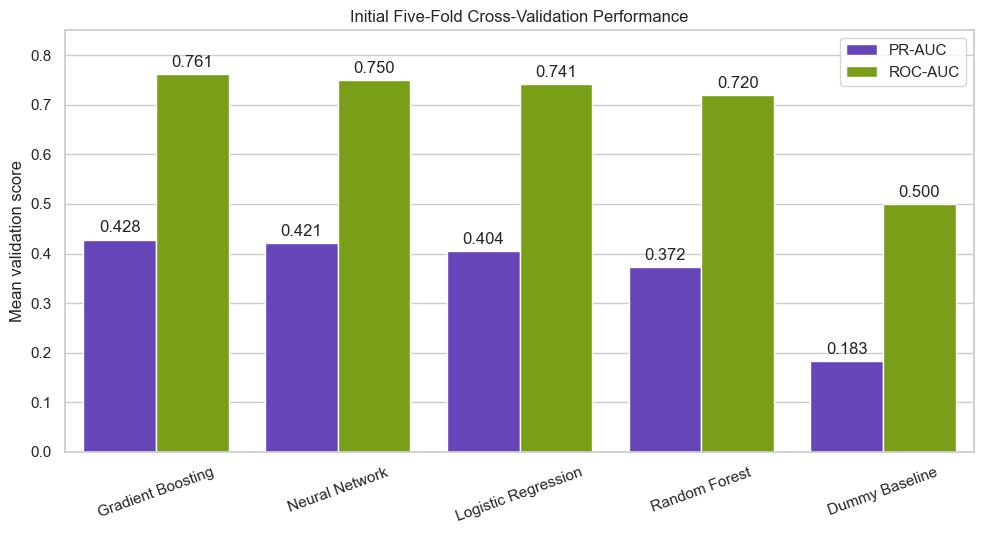

In [10]:
# Plot the table above as a grouped bar chart: PR-AUC and ROC-AUC side by side
# for all five models, so the untuned ranking is easy to read at a glance.

# Reshape to one row per model-metric pair, which is the format seaborn expects.
initial_auc_plot_data = initial_comparison.melt(
    id_vars="Model",
    value_vars=["average_precision_mean", "roc_auc_mean"],
    var_name="Metric",
    value_name="Score",
)

# Rename the raw column names to the labels shown in the legend.
initial_auc_plot_data["Metric"] = initial_auc_plot_data["Metric"].map(
    {
        "average_precision_mean": "PR-AUC",
        "roc_auc_mean": "ROC-AUC",
    }
)

# One bar group per model, with a separate colored bar for each metric.
plt.figure(figsize=(10, 5.5))
axis = sns.barplot(
    data=initial_auc_plot_data,
    x="Model",
    y="Score",
    hue="Metric",
    palette=[PURPLE, GREEN],
)

axis.set_title("Initial Five-Fold Cross-Validation Performance")
axis.set_xlabel("")
axis.set_ylabel("Mean validation score")
axis.set_ylim(0, 0.85)
axis.tick_params(axis="x", rotation=20)
axis.legend(title="")

# Print each score on its bar so exact values can be compared without guessing.
for container in axis.containers:
    axis.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()


All four learned models beat the dummy baseline on both ranking metrics. The dummy scores 0.183 PR-AUC (exactly the cavity rate, which is what pure guessing gets) and 0.500 ROC-AUC (no better than a coin flip). Every real model lands between 0.372 and 0.428 PR-AUC and between 0.720 and 0.761 ROC-AUC, so the predictors genuinely carry information about untreated cavities.

Gradient boosting leads at 0.428 PR-AUC, the neural network follows at 0.421, and logistic regression reaches 0.404. Random forest is last at 0.372 because its trees are still completely unrestricted and are memorizing the training folds. Tuning in the next section addresses that.

**Recall** is the share of true cavity cases the model actually catches. Gradient boosting's recall of 0.156 means that out of every 100 participants who really have an untreated cavity, it flags only about 16 and misses the other 84. **Precision** is the opposite view: of the people the model does flag, what share truly have a cavity. Gradient boosting's precision of 0.584 means it is right about 58% of the time when it commits to a positive prediction. So the model is cautious rather than broken. It rarely says "cavity," but it is reasonably trustworthy when it does.

That caution comes from the 0.50 cutoff, not from the model itself. A participant is only labeled a cavity case if the model is more than 50% confident, and since fewer than one in five people actually have one, the models rarely reach that confidence level. Almost everyone gets labeled "no cavity."

This also explains why **accuracy** (the share of all predictions that are correct) is the wrong metric here. The dummy never predicts a single cavity and still scores 0.817, while the best model scores only 0.825. Labeling everyone "no cavity" is automatically right about 82% of the time, so accuracy barely moves no matter how good the model is.

The fix is a different cutoff, not a different model. PR-AUC and ROC-AUC already show the models rank participants well, pushing cavity cases toward higher probabilities even when those probabilities never cross 0.50. Lowering the threshold converts that ranking ability into real detections, and a later section selects each model's threshold using out-of-fold predictions from the training data only.


## Hyperparameter Tuning

The scores above are respectable but not remarkable, and every model so far has been running on settings that were chosen by hand rather than tested. This section asks whether better settings are available.

Hyperparameters control how a model learns rather than being learned directly from the data. Examples include the number of trees, tree depth, regularization strength, and neural-network architecture.

Logistic regression has a small search space, so every listed combination is tested with `GridSearchCV`. The other models have many possible combinations, so `RandomizedSearchCV` tests 12 reproducibly selected combinations for each model. This provides a useful search without making the notebook unnecessarily slow.

Tuning is worth doing, but it is not a guaranteed fix. It will not turn a 0.43 PR-AUC into a 0.70 one. Its real value here is diagnostic: a model that improves a lot was being held back by its settings, while a model that barely moves was already close to the best it can do with these predictors. Both outcomes appear below.

Every search selects its best setting using mean cross-validation PR-AUC. The permanent test set is still not involved.


In [11]:
# Logistic regression only needs a small complete grid.
logistic_search = GridSearchCV(
    estimator=clone(initial_models["Logistic Regression"]),
    param_grid={
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__class_weight": [None, "balanced"],
    },
    scoring=scoring,
    refit="average_precision",
    cv=cross_validation,
    n_jobs=-1,
    return_train_score=False,
)


# The random forest search controls tree size, smoothing, predictor sampling,
# and whether the minority cavity class receives additional weight.
random_forest_search = RandomizedSearchCV(
    estimator=clone(initial_models["Random Forest"]),
    param_distributions={
        "model__n_estimators": [250, 400, 600],
        "model__max_depth": [None, 8, 12, 18],
        "model__min_samples_leaf": [1, 3, 5, 10],
        "model__min_samples_split": [2, 5, 10],
        "model__max_features": ["sqrt", 0.5, 0.8],
        "model__class_weight": [None, "balanced"],
    },
    n_iter=12,
    scoring=scoring,
    refit="average_precision",
    cv=cross_validation,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=False,
)


# Gradient boosting balances the number and depth of trees against the learning
# rate. Subsampling can also reduce overfitting by changing the rows seen by
# each new tree.
gradient_boosting_search = RandomizedSearchCV(
    estimator=clone(initial_models["Gradient Boosting"]),
    param_distributions={
        "model__n_estimators": [100, 150, 250],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [1, 2, 3],
        "model__min_samples_leaf": [5, 10, 20],
        "model__subsample": [0.7, 0.85, 1.0],
        "model__max_features": [None, "sqrt"],
    },
    n_iter=12,
    scoring=scoring,
    refit="average_precision",
    cv=cross_validation,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=False,
)


# The neural-network search tests both one- and two-hidden-layer structures,
# two activation functions, regularization, learning rate, and batch size.
neural_network_search = RandomizedSearchCV(
    estimator=clone(initial_models["Neural Network"]),
    param_distributions={
        "model__hidden_layer_sizes": [(32,), (64,), (64, 32), (128, 64)],
        "model__activation": ["relu", "tanh"],
        "model__alpha": [0.00001, 0.0001, 0.001, 0.01],
        "model__learning_rate_init": [0.0005, 0.001, 0.003],
        "model__batch_size": [64, 128],
    },
    n_iter=12,
    scoring=scoring,
    refit="average_precision",
    cv=cross_validation,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=False,
)

model_searches = {
    "Logistic Regression": logistic_search,
    "Random Forest": random_forest_search,
    "Gradient Boosting": gradient_boosting_search,
    "Neural Network": neural_network_search,
}

print("Search objects created. No model has been tuned in this cell yet.")

Search objects created. No model has been tuned in this cell yet.


## Running the Searches

The next cell performs the most computationally expensive part of the notebook. It fits each candidate across all five folds and then automatically refits the best configuration on the complete training dataset.

The exact runtime depends on the computer, but the printed times make the process transparent.

In [12]:
search_times = {}

for model_name, search in model_searches.items():
    print(f"Tuning {model_name}...")
    start_time = time.perf_counter()

    search.fit(X, y)

    elapsed = time.perf_counter() - start_time
    search_times[model_name] = elapsed
    print(
        f"  Finished in {elapsed:.1f} seconds | "
        f"best PR-AUC = {search.best_score_:.3f}"
    )

Tuning Logistic Regression...
  Finished in 0.8 seconds | best PR-AUC = 0.405
Tuning Random Forest...
  Finished in 56.0 seconds | best PR-AUC = 0.430
Tuning Gradient Boosting...
  Finished in 7.7 seconds | best PR-AUC = 0.430
Tuning Neural Network...
  Finished in 38.2 seconds | best PR-AUC = 0.423


In [13]:
# Put every selected hyperparameter on its own row so the result is easier to
# read than four long Python dictionaries.
parameter_rows = []

for model_name, search in model_searches.items():
    for parameter, value in search.best_params_.items():
        parameter_rows.append(
            {
                "Model": model_name,
                "Hyperparameter": parameter.replace("model__", ""),
                "Selected value": str(value),
            }
        )

selected_parameters = pd.DataFrame(parameter_rows)

tuning_summary = pd.DataFrame(
    {
        "Model": list(model_searches.keys()),
        "Best cross-validation PR-AUC": [
            search.best_score_ for search in model_searches.values()
        ],
        "Search time (seconds)": [
            search_times[model_name] for model_name in model_searches
        ],
    }
).sort_values("Best cross-validation PR-AUC", ascending=False)

display(
    tuning_summary.round(
        {
            "Best cross-validation PR-AUC": 3,
            "Search time (seconds)": 1,
        }
    )
)

selected_parameters

,Model,Best cross-validation PR-AUC,Search time (seconds)
1,Random Forest,0.430,56.0
2,Gradient Boosting,0.430,7.7
3,Neural Network,0.423,38.2
0,Logistic Regression,0.405,0.8


,Model,Hyperparameter,Selected value
0,Logistic Regression,C,0.1
1,Logistic Regression,class_weight,None
2,Random Forest,n_estimators,600
3,Random Forest,min_samples_split,5
4,Random Forest,min_samples_leaf,5
5,Random Forest,max_features,sqrt
6,Random Forest,max_depth,None
7,Random Forest,class_weight,None
8,Gradient Boosting,subsample,0.7
9,Gradient Boosting,n_estimators,250


## Comparing the Tuned Models

Each search was given the full `scoring` dictionary rather than a single metric, so it recorded all seven evaluation metrics for every candidate on every fold. The `refit="average_precision"` setting only decided which metric chose the winner; it did not limit what was measured.

That means the selected candidate's recall, precision, F1, and accuracy were already calculated during the search and stored in `search.cv_results_`. Reading them back with `search.best_index_` avoids refitting four tuned models across five folds a second time to recover numbers that already exist.

These values are internal development estimates rather than final results. They are likely to be slightly optimistic, and the reason is worth stating directly: the same five folds performed two jobs at once. They selected the hyperparameters, and they produced the score being reported.

Choosing the best of twelve candidates and then reporting that candidate's score is similar to sitting twelve practice exams and reporting only the highest mark. The number is not invented, but part of it reflects genuine ability and part of it reflects which attempt happened to suit the particular questions. With twelve candidates the inflation is usually small, though it is real and it always points in the same direction.

This is why the permanent test set is still necessary. Notebook 5 will evaluate the saved pipelines on participants that took no part in selecting either the hyperparameters or the thresholds, so its results carry no comparable advantage.


In [14]:
# Reads each search's already-selected winner instead of re-running cross_validate.
def summarize_selected_search(model_name, search):
    """Collect all validation metrics for the search's selected candidate."""
    best_index = search.best_index_
    row = {"Model": model_name}

    for metric_name in scoring:
        row[f"{metric_name}_mean"] = search.cv_results_[
            f"mean_test_{metric_name}"
        ][best_index]
        row[f"{metric_name}_std"] = search.cv_results_[
            f"std_test_{metric_name}"
        ][best_index]

    row["fit_time_seconds"] = search.cv_results_["mean_fit_time"][best_index]
    return row


tuned_rows = [
    summarize_selected_search(model_name, search)
    for model_name, search in model_searches.items()
]

# Rebuild the same dummy-plus-models comparison used for the untuned models.
development_comparison = pd.concat(
    [dummy_summary, pd.DataFrame(tuned_rows)],
    ignore_index=True,
).sort_values("average_precision_mean", ascending=False)

development_comparison = development_comparison.reset_index(drop=True)

formatted_model_table(development_comparison)


,Model,average_precision_mean,average_precision_std,roc_auc_mean,roc_auc_std,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std,balanced_accuracy_mean,balanced_accuracy_std,accuracy_mean,accuracy_std,fit_time_seconds
0,Random Forest,0.430,0.031,0.755,0.015,0.139,0.023,0.589,0.059,0.224,0.033,0.559,0.012,0.825,0.005,5.80
1,Gradient Boosting,0.430,0.041,0.762,0.017,0.163,0.016,0.579,0.062,0.254,0.024,0.568,0.010,0.825,0.006,0.69
2,Neural Network,0.423,0.042,0.747,0.017,0.128,0.044,0.605,0.081,0.208,0.059,0.554,0.020,0.825,0.007,4.57
3,Logistic Regression,0.405,0.036,0.741,0.015,0.118,0.016,0.598,0.094,0.197,0.025,0.550,0.009,0.824,0.006,0.03
4,Dummy Baseline,0.183,0.000,0.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.500,0.000,0.817,0.000,0.02


In [15]:
# Compare each model with its own untuned version. This makes it clear whether
# the search produced a meaningful improvement or only a tiny numerical change.
initial_pr_auc = initial_comparison.set_index("Model")["average_precision_mean"]
tuned_pr_auc = development_comparison.set_index("Model")["average_precision_mean"]

tuning_gain = pd.DataFrame(
    {
        "Model": list(model_searches.keys()),
        "Initial PR-AUC": [
            initial_pr_auc[model_name] for model_name in model_searches
        ],
        "Tuned PR-AUC": [
            tuned_pr_auc[model_name] for model_name in model_searches
        ],
    }
)
tuning_gain["PR-AUC change"] = (
    tuning_gain["Tuned PR-AUC"] - tuning_gain["Initial PR-AUC"]
)
tuning_gain = tuning_gain.sort_values("PR-AUC change", ascending=False)

tuning_gain.round(3)

,Model,Initial PR-AUC,Tuned PR-AUC,PR-AUC change
1,Random Forest,0.372,0.430,0.058
3,Neural Network,0.421,0.423,0.002
2,Gradient Boosting,0.428,0.430,0.002
0,Logistic Regression,0.404,0.405,0.001


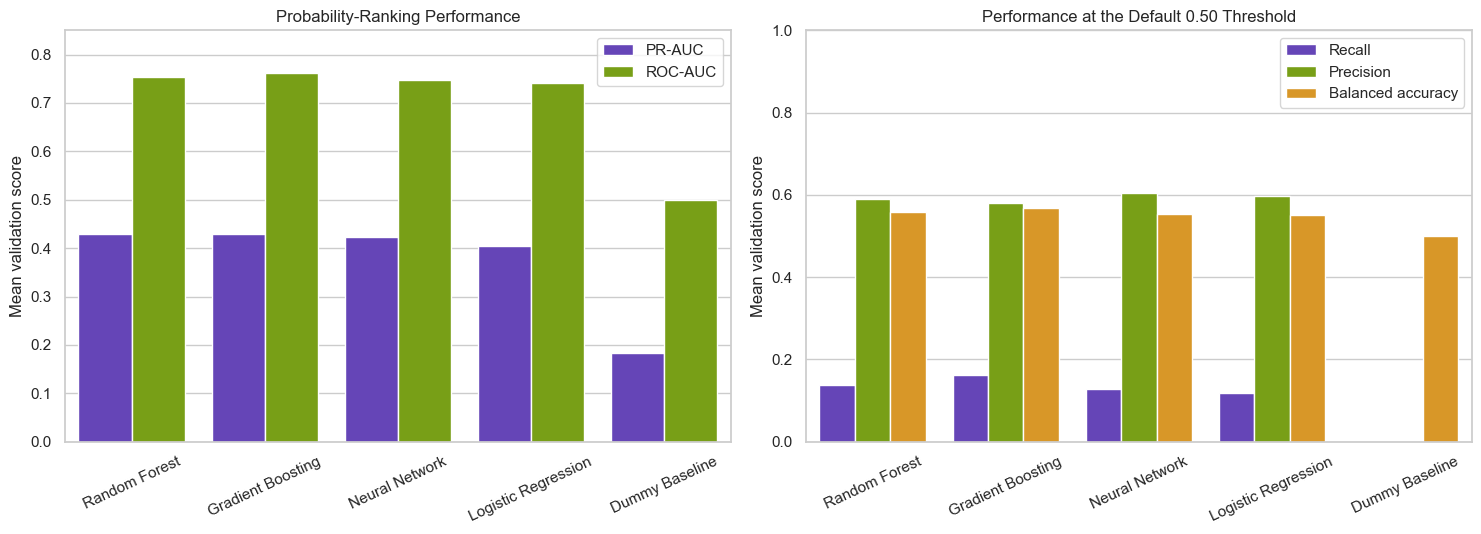

In [16]:
# Show ranking metrics on the left and default-threshold classification metrics
# on the right. The threshold-dependent metrics will change later.
figure, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ranking_plot = development_comparison.melt(
    id_vars="Model",
    value_vars=["average_precision_mean", "roc_auc_mean"],
    var_name="Metric",
    value_name="Score",
)
ranking_plot["Metric"] = ranking_plot["Metric"].map(
    {
        "average_precision_mean": "PR-AUC",
        "roc_auc_mean": "ROC-AUC",
    }
)

sns.barplot(
    data=ranking_plot,
    x="Model",
    y="Score",
    hue="Metric",
    palette=[PURPLE, GREEN],
    ax=axes[0],
)
axes[0].set_title("Probability-Ranking Performance")
axes[0].set_xlabel("")
axes[0].set_ylabel("Mean validation score")
axes[0].set_ylim(0, 0.85)
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend(title="")


classification_plot = development_comparison.melt(
    id_vars="Model",
    value_vars=[
        "recall_mean",
        "precision_mean",
        "balanced_accuracy_mean",
    ],
    var_name="Metric",
    value_name="Score",
)
classification_plot["Metric"] = classification_plot["Metric"].map(
    {
        "recall_mean": "Recall",
        "precision_mean": "Precision",
        "balanced_accuracy_mean": "Balanced accuracy",
    }
)

sns.barplot(
    data=classification_plot,
    x="Model",
    y="Score",
    hue="Metric",
    palette=[PURPLE, GREEN, ORANGE],
    ax=axes[1],
)
axes[1].set_title("Performance at the Default 0.50 Threshold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Mean validation score")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=25)
axes[1].legend(title="")

plt.tight_layout()
plt.show()

The learned models provide substantially better probability ranking than the dummy baseline. Gradient boosting and random forest are essentially tied for the highest mean training PR-AUC at about 0.430. The neural network follows closely at about 0.423, while logistic regression reaches about 0.405. These differences are small enough that the untouched test set is still needed before deciding which model generalizes best.

Random forest shows by far the largest tuning improvement, rising from about 0.373 to 0.430 PR-AUC. The selected `min_samples_leaf=5` forces each terminal leaf to contain several participants, which smooths the forest and reduces the overfitting seen with the initial unrestricted trees.

The searches also considered `class_weight="balanced"` for logistic regression and random forest, but PR-AUC selected the unweighted versions. Class weighting can move a model's decision boundary and change its default-threshold recall, but it does not automatically improve probability ranking—which is what PR-AUC measures. Thresholds are handled separately below.

The right graph also reinforces why a 0.50 threshold should not be accepted automatically. Recall at that cutoff is only 0.118-0.163 across the four models, even though PR-AUC already showed they rank participants reasonably well and precision at 0.50 looks respectable, around 0.58-0.61. That combination means a model is usually right on the rare occasions it does flag someone, but it stays silent for the large majority of actual cavity cases. Balanced accuracy tells the same story from a different angle: at 0.55-0.57 it sits barely above the 0.50 a coin flip would give, because averaging a near-zero cavity recall with a near-perfect no-cavity recall still lands close to the middle. None of this means the models are weak; it means 0.50 is the wrong cutoff for a target this imbalanced, which the "Selecting Classification Thresholds" section addresses directly by choosing each model's cutoff from its own out-of-fold probabilities instead of an arbitrary midpoint.


## Checking Whether the Top Models Are Meaningfully Different

The five-fold means place gradient boosting and random forest extremely close together, and their fold-to-fold standard deviations overlap. Comparing those standard deviations as if the models used unrelated samples would waste the fact that both models were evaluated on the same validation folds.

This section uses three repetitions of five-fold stratified cross-validation. It then subtracts the two models' PR-AUC values *within each matching fold*. The paired differences show whether one model consistently wins on the same participants or whether the ranking changes with the split.

The hyperparameters were still selected using this training dataset, so this is a stability check rather than a new unbiased performance estimate. The permanent test set remains the final comparison.

In [17]:
# Three separate 5-fold splits (15 scores per model) instead of just one,
# so the paired comparison below has more than 5 differences to look at.
repeated_cross_validation = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=RANDOM_STATE,
)

# The two models with the highest tuned PR-AUC, currently gradient boosting
# and random forest.
top_two_models = (
    development_comparison.loc[
        development_comparison["Model"] != "Dummy Baseline",
        "Model",
    ]
    .head(2)
    .tolist()
)

repeated_scores = {}

# Re-score each model's already-tuned pipeline across the 15 repeated folds.
for model_name in top_two_models:
    print(f"Repeating cross-validation for {model_name}...")

    results = cross_validate(
        clone(model_searches[model_name].best_estimator_),
        X,
        y,
        cv=repeated_cross_validation,
        scoring="average_precision",
        n_jobs=-1,
        error_score="raise",
    )
    repeated_scores[model_name] = results["test_score"]


# One row per fold, with both models' scores side by side since they were
# tested on the exact same participants in that fold.
repeated_fold_results = pd.DataFrame(
    {
        "Repeat": np.repeat(np.arange(1, 4), 5),
        "Fold": np.tile(np.arange(1, 6), 3),
        top_two_models[0]: repeated_scores[top_two_models[0]],
        top_two_models[1]: repeated_scores[top_two_models[1]],
    }
)

# Subtracting within each fold is the paired comparison: it asks which model
# won on that specific set of participants, rather than comparing two
# unrelated-looking averages.
difference_column = f"{top_two_models[0]} minus {top_two_models[1]}"
repeated_fold_results[difference_column] = (
    repeated_fold_results[top_two_models[0]]
    - repeated_fold_results[top_two_models[1]]
)

repeated_summary = pd.DataFrame(
    {
        "Model": top_two_models,
        "Mean repeated PR-AUC": [
            repeated_fold_results[model_name].mean()
            for model_name in top_two_models
        ],
        "Standard deviation": [
            repeated_fold_results[model_name].std(ddof=1)
            for model_name in top_two_models
        ],
        # How many of the 15 folds each model actually won, not just the
        # overall averages.
        "Higher-scoring folds": [
            int((repeated_fold_results[difference_column] > 0).sum()),
            int((repeated_fold_results[difference_column] < 0).sum()),
        ],
    }
)

# If these paired differences cluster near zero, the two models are
# effectively tied; if they lean consistently one way, one model wins.
paired_difference_summary = pd.DataFrame(
    {
        "Paired comparison": [
            "Mean PR-AUC difference",
            "Median PR-AUC difference",
            "Smallest fold difference",
            "Largest fold difference",
        ],
        "Result": [
            repeated_fold_results[difference_column].mean(),
            repeated_fold_results[difference_column].median(),
            repeated_fold_results[difference_column].min(),
            repeated_fold_results[difference_column].max(),
        ],
    }
)

display(repeated_summary.round(3))
paired_difference_summary.round(3)


Repeating cross-validation for Random Forest...
Repeating cross-validation for Gradient Boosting...


,Model,Mean repeated PR-AUC,Standard deviation,Higher-scoring folds
0,Random Forest,0.429,0.023,9
1,Gradient Boosting,0.428,0.029,6


,Paired comparison,Result
0,Mean PR-AUC difference,0.001
1,Median PR-AUC difference,0.006
2,Smallest fold difference,-0.019
3,Largest fold difference,0.018


The repeated comparison confirms that the apparent lead is not stable. Random forest has mean PR-AUC 0.429 compared with 0.428 for gradient boosting and scores higher in 9 of the 15 paired folds. The mean gradient-boosting-minus-random-forest difference is only -0.001, with individual fold differences ranging from -0.017 to 0.019. The practical conclusion is that the two models are tied on the training data.

No p-value is reported because folds from repeated cross-validation are not fully independent observations. The purpose is to show stability and uncertainty honestly, not to manufacture a claim that one algorithm is definitively superior.

## Generating Out-of-Fold Predictions

Each tuned pipeline was already refit on all 10,572 training participants when its search finished. Asking that fitted model for probabilities on those same participants would mean scoring people it already memorized during training, which tends to look more confident than the model actually deserves. Any threshold chosen from probabilities like that would be unrealistically optimistic.

`cross_val_predict` avoids this by reusing the same 5-fold split as the rest of the notebook, but instead of returning a score it returns the prediction itself. For each fold in turn, it trains a fresh copy of the pipeline on the other four folds and predicts only on the fold that was held out. Repeating this across all five folds gives every participant a probability from a version of the model that never saw them during training, which is what "out-of-fold" means: nobody grades their own homework.

The result is one training-only out-of-fold probability per participant for each tuned model, stored alongside the fold each participant fell in. These honest probabilities are what support fair curve comparisons and threshold selection later in this notebook, all without touching the test set.


In [18]:
# Each search object already refitted its selected pipeline on the complete
# training set. Those fitted versions will later be saved as the final models.
best_models = {
    model_name: search.best_estimator_
    for model_name, search in model_searches.items()
}

out_of_fold_probabilities = pd.DataFrame(
    {
        "SEQN": training_data["SEQN"].values,
        "has_cavity": y.values,
    }
)

# Record the validation fold for each participant. The same deterministic
# splitter is used by cross_val_predict, so these labels let us check how stable
# the selected threshold is across the five folds.
fold_assignment = np.empty(len(y), dtype=int)

for fold_number, (_, validation_indices) in enumerate(
    cross_validation.split(X, y),
    start=1,
):
    fold_assignment[validation_indices] = fold_number

out_of_fold_probabilities["CV_fold"] = fold_assignment

for model_name, model in best_models.items():
    print(f"Creating out-of-fold predictions for {model_name}...")

    probabilities = cross_val_predict(
        clone(model),
        X,
        y,
        cv=cross_validation,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]

    out_of_fold_probabilities[model_name] = probabilities

assert len(out_of_fold_probabilities) == len(training_data)
assert out_of_fold_probabilities.isna().sum().sum() == 0

out_of_fold_probabilities.head()

Creating out-of-fold predictions for Logistic Regression...
Creating out-of-fold predictions for Random Forest...
Creating out-of-fold predictions for Gradient Boosting...
Creating out-of-fold predictions for Neural Network...


,SEQN,has_cavity,CV_fold,Logistic Regression,Random Forest,Gradient Boosting,Neural Network
0,109795,0,1,0.064559,0.075530,0.045442,0.061394
1,121970,0,2,0.111884,0.228128,0.098527,0.077966
2,121273,0,4,0.053133,0.068173,0.045671,0.036385
3,120598,1,5,0.441496,0.487279,0.541044,0.472782
4,110345,0,5,0.042123,0.064549,0.036809,0.048628


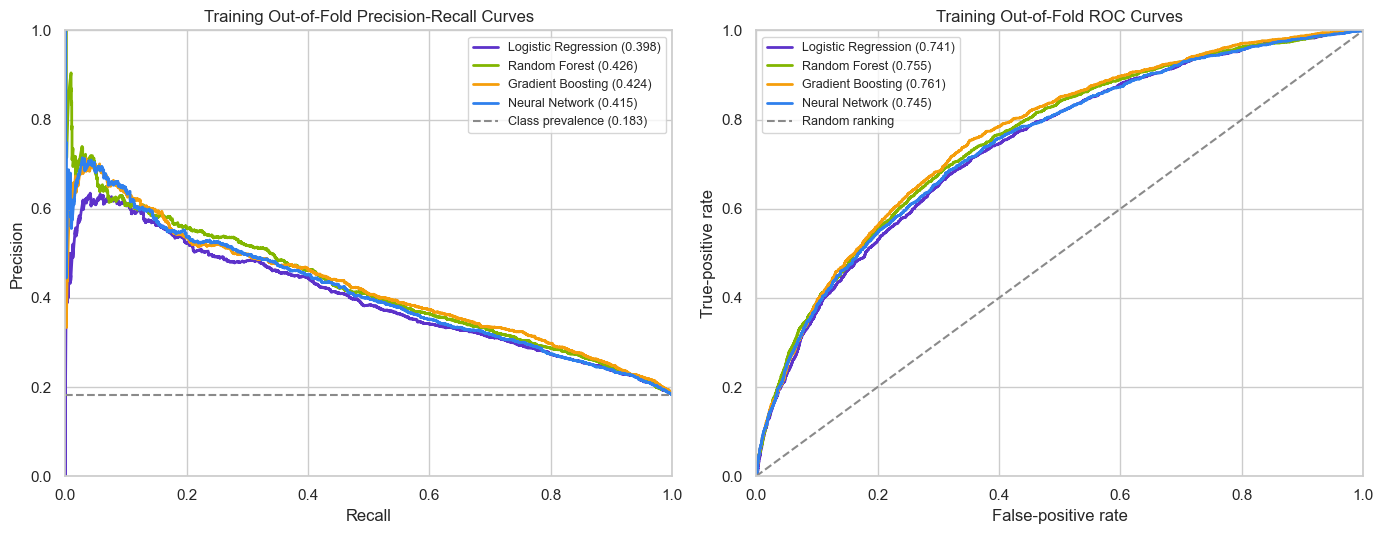

In [19]:
# Plot both curves because they answer different questions. PR curves focus on
# the cavity class, while ROC curves summarize overall ranking.
figure, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for model_name in best_models:
    probabilities = out_of_fold_probabilities[model_name]

    precision, recall, _ = precision_recall_curve(y, probabilities)
    false_positive_rate, true_positive_rate, _ = roc_curve(y, probabilities)

    pr_auc = average_precision_score(y, probabilities)
    roc_auc_value = roc_auc_score(y, probabilities)

    axes[0].plot(
        recall,
        precision,
        color=MODEL_COLORS[model_name],
        linewidth=2,
        label=f"{model_name} ({pr_auc:.3f})",
    )
    axes[1].plot(
        false_positive_rate,
        true_positive_rate,
        color=MODEL_COLORS[model_name],
        linewidth=2,
        label=f"{model_name} ({roc_auc_value:.3f})",
    )

axes[0].axhline(
    y.mean(),
    color=GRAY,
    linestyle="--",
    label=f"Class prevalence ({y.mean():.3f})",
)
axes[0].set_title("Training Out-of-Fold Precision-Recall Curves")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=9)

axes[1].plot([0, 1], [0, 1], color=GRAY, linestyle="--", label="Random ranking")
axes[1].set_title("Training Out-of-Fold ROC Curves")
axes[1].set_xlabel("False-positive rate")
axes[1].set_ylabel("True-positive rate")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


The curves show the tradeoff created by changing the probability threshold. Increasing recall generally lowers precision because the model labels more participants as possible cavity cases.

The values in these figures are still development results, but every plotted probability came from a fold that did not train on that participant. Each point on a curve comes from sweeping through many possible thresholds and asking, at each one, how the model did on people it never trained on. That is only possible because the previous section already built one honest, out-of-fold probability per participant with `cross_val_predict`; this cell reuses that same table rather than generating any new predictions. Plotting probabilities from a model scored on its own training rows instead would trace out a curve that looks better than the model actually performs, since the model would already know the answers for those rows.


## Checking Probability Calibration

Ranking metrics do not show whether a predicted probability has a literal interpretation. A well-calibrated model should produce cavities in roughly 20% of participants assigned a probability near 0.20, roughly 40% of those assigned a probability near 0.40, and so on.

The reliability diagram groups the existing out-of-fold predictions into 10 equally sized bins and compares mean predicted probability with observed cavity frequency. The Brier score measures squared probability error, so lower values are better. A prevalence-only dummy probability is included as a reference.

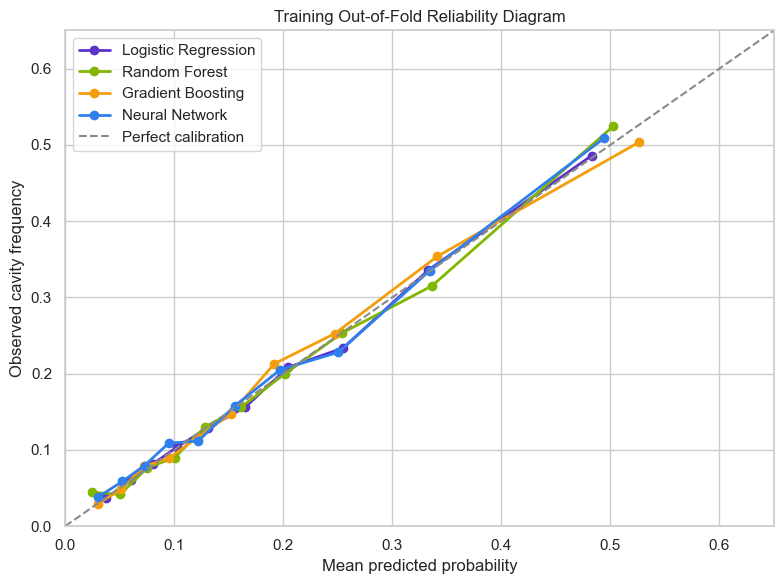

,Model,Brier score,Mean predicted probability,Observed prevalence
0,Gradient Boosting,0.128,0.183,0.183
1,Random Forest,0.129,0.184,0.183
2,Neural Network,0.130,0.180,0.183
3,Logistic Regression,0.131,0.185,0.183
4,Dummy Baseline,0.150,0.183,0.183


In [20]:
calibration_rows = [
    {
        "Model": "Dummy Baseline",
        "Brier score": brier_score_loss(
            y,
            np.repeat(y.mean(), len(y)),
        ),
        "Mean predicted probability": y.mean(),
        "Observed prevalence": y.mean(),
    }
]

plt.figure(figsize=(8, 6))

for model_name in best_models:
    probabilities = out_of_fold_probabilities[model_name].to_numpy()

    observed_fraction, mean_probability = calibration_curve(
        y,
        probabilities,
        n_bins=10,
        strategy="quantile",
    )

    plt.plot(
        mean_probability,
        observed_fraction,
        marker="o",
        linewidth=2,
        color=MODEL_COLORS[model_name],
        label=model_name,
    )

    calibration_rows.append(
        {
            "Model": model_name,
            "Brier score": brier_score_loss(y, probabilities),
            "Mean predicted probability": probabilities.mean(),
            "Observed prevalence": y.mean(),
        }
    )

plt.plot(
    [0, 1],
    [0, 1],
    color=GRAY,
    linestyle="--",
    label="Perfect calibration",
)
plt.title("Training Out-of-Fold Reliability Diagram")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed cavity frequency")
plt.xlim(0, 0.65)
plt.ylim(0, 0.65)
plt.legend()
plt.tight_layout()
plt.show()

calibration_summary = pd.DataFrame(calibration_rows).sort_values(
    "Brier score"
).reset_index(drop=True)

calibration_summary.round(3)

Calibration and discrimination are different. Discrimination (PR-AUC, ROC-AUC) asks whether a model ranks cavity cases above non-cavity cases; calibration asks whether its actual probability numbers can be trusted. The reliability diagram checks this by grouping participants into 10 buckets by predicted probability and comparing each bucket's average prediction (x-axis) against the real share of that bucket that had a cavity (y-axis). A dot on the dashed diagonal means the model was honest for that bucket; above the line means it underestimated risk there, below means it overestimated.

The Brier score summarizes the same idea as one number: the average squared gap between each person's predicted probability and their actual 0/1 outcome, so confidently wrong predictions are penalized far more than cautious ones. Lower is better.

In this case, all four reliability curves stay close to the diagonal, and their Brier scores (0.128-0.131) beat the prevalence-only dummy (0.150), so the probabilities are reasonably trustworthy, not just good at ranking.

These are still training-only checks. The models are not recalibrated here because that would add another modeling decision that must itself be validated. Notebook 5 will show whether this holds on the untouched test set.


## Selecting Classification Thresholds

A probability threshold converts a continuous cavity probability into a 0/1 prediction. The conventional threshold of 0.50 is not automatically appropriate when cavity cases are the minority class.

Initially I maximized out-of-fold F1, which weights precision and recall equally. That weighting has no real justification for a screening tool: missing an untreated cavity lets real disease progress unnoticed, while an unnecessary referral only costs a checkup that most adults should be getting anyway. Treating those two mistakes as equally costly was the wrong default, so this section instead sets a recall floor. `TARGET_RECALL = 0.80` states directly what the tool is required to do: detect at least 80% of untreated cavity cases.

Because the out-of-fold probabilities were already shown to be reasonably calibrated, a threshold `t` can be read as an implicit cost assumption: it treats a missed cavity as `(1 − t) / t` times worse than an unnecessary referral. A sensitivity table further down shows how the threshold, the share of participants flagged, and that implied cost ratio all move together as the recall requirement is raised or lowered, so the 0.80 choice is visible as a dial rather than a fact.

Picking the exact cutoff where estimated recall first reaches 0.80 would leave no safety margin. With roughly 1,900 cavity cases in the training data, a cutoff that only just clears the floor on this sample could easily fall short of it on a new one by chance alone. To avoid locking in a threshold that merely looks safe, each candidate cutoff's recall is judged by the lower edge of its 95% confidence interval (a Wilson interval, the standard interval for a proportion) rather than by the raw estimate. The threshold selected is the strictest cutoff whose lower bound still clears 80% recall, which costs a small amount of precision in exchange for a threshold that is not sitting exactly on the edge of failing.

The maximum-F1 threshold is still calculated for every model and reported alongside the recall-floor result, but only as a reference point. It plays no role in the decision: the recall floor is the sole rule that determines the threshold each model carries forward, and the model-threshold pair carried into Notebook 5 is fixed here, before the test set is opened, rather than chosen afterward from whichever combination happens to score best.

Two separate checks follow the main table. The first repeats the recall-floor rule inside each validation fold, which shows how much the rule itself moves at one-fifth the sample size which is a diagnostic about the rule, not an estimate of the pooled threshold's own uncertainty. The second is a non-circular transfer check: for each fold, the threshold is selected using only the other four folds and then scored on the fold that never influenced that selection. That second check is the more honest preview of what Notebook 5's test-set recall is likely to look like.


In [21]:
# The recall floor this screening tool is designed around. Raising it finds
# more cavity cases at the cost of more referrals; lowering it does the reverse.
TARGET_RECALL = 0.80

# Two-sided 95% normal quantile, used for the Wilson interval below.
Z_95 = 1.959964


def wilson_lower_bound(successes, trials, z=Z_95):
    """Lower edge of a 95% confidence interval for a proportion.

    Used on recall (successes = cavity cases caught, trials = cavity cases
    total) so threshold selection can require a cutoff to clear the recall
    floor with statistical margin, not just touch it at the raw estimate.
    """
    if trials == 0:
        return 0.0
    proportion = successes / trials
    denominator = 1 + z**2 / trials
    center = (proportion + z**2 / (2 * trials)) / denominator
    margin = (
        z * np.sqrt(proportion * (1 - proportion) / trials + z**2 / (4 * trials**2))
    ) / denominator
    return center - margin


def metrics_at_threshold(true_labels, probabilities, threshold):
    """Calculate classification metrics after applying one probability cutoff."""
    predictions = (probabilities >= threshold).astype(int)
    true_labels = np.asarray(true_labels)
    cases_caught = int(((predictions == 1) & (true_labels == 1)).sum())
    total_cases = int((true_labels == 1).sum())

    return {
        "Threshold": threshold,
        "Recall": recall_score(true_labels, predictions, zero_division=0),
        "Recall lower 95%": wilson_lower_bound(cases_caught, total_cases),
        "Precision": precision_score(true_labels, predictions, zero_division=0),
        "F1": f1_score(true_labels, predictions, zero_division=0),
        "Balanced accuracy": balanced_accuracy_score(true_labels, predictions),
        "Accuracy": accuracy_score(true_labels, predictions),
        "Share flagged": predictions.mean(),
    }


def select_threshold_by_recall_floor(
    true_labels, probabilities, thresholds, target_recall
):
    """Select the strictest threshold whose recall reliably clears the floor.

    Recall never increases as the threshold rises, so every cutoff that clears
    the floor sits at or below one boundary cutoff. Taking the highest of them
    flags the fewest participants; on this data it also happens to be the
    precision-maximizing cutoff among those that qualify, which the assertion
    below checks rather than assumes.
    """
    candidate_table = pd.DataFrame(
        [
            metrics_at_threshold(true_labels, probabilities, threshold)
            for threshold in thresholds
        ]
    )

    qualifying = candidate_table.loc[
        candidate_table["Recall lower 95%"] >= target_recall
    ]

    # If not even the most lenient cutoff clears the floor with confidence,
    # flagging everyone is the only cutoff guaranteed to reach it (recall = 1).
    if qualifying.empty:
        fallback = pd.Series(metrics_at_threshold(true_labels, probabilities, 0.0))
        return fallback, candidate_table, False

    selected = qualifying.loc[qualifying["Threshold"].idxmax()]

    assert selected["Threshold"] == qualifying["Threshold"].max()
    assert selected["Recall lower 95%"] >= target_recall - 1e-9
    assert np.isclose(selected["Precision"], qualifying["Precision"].max()), (
        "The highest qualifying threshold is not the precision-maximizing one "
        "for this model; the monotonicity this rule relies on does not hold here."
    )

    return selected, candidate_table, True


def select_threshold_by_f1(true_labels, probabilities, thresholds):
    """Select the maximum-F1 threshold. Kept only as a secondary reference."""
    candidate_table = pd.DataFrame(
        [
            metrics_at_threshold(true_labels, probabilities, threshold)
            for threshold in thresholds
        ]
    )

    # The second sorting value gives a reproducible tie-breaker.
    candidate_table["Distance from 0.50"] = (
        candidate_table["Threshold"] - 0.50
    ).abs()
    return candidate_table.sort_values(
        ["F1", "Distance from 0.50"],
        ascending=[False, True],
    ).iloc[0]


metric_keys = [
    "Threshold",
    "Recall",
    "Recall lower 95%",
    "Precision",
    "F1",
    "Balanced accuracy",
    "Accuracy",
    "Share flagged",
]

threshold_rows = []
fold_threshold_rows = []
transfer_check_rows = []
floor_met_by_model = {}
candidate_thresholds = np.round(np.arange(0.05, 0.951, 0.005), 3)

for model_name in best_models:
    probabilities = out_of_fold_probabilities[model_name].to_numpy()

    selected, _, floor_met = select_threshold_by_recall_floor(
        y,
        probabilities,
        candidate_thresholds,
        TARGET_RECALL,
    )
    floor_met_by_model[model_name] = floor_met

    default_metrics = metrics_at_threshold(y, probabilities, 0.50)
    default_metrics.update({"Model": model_name, "Threshold type": "Default"})
    threshold_rows.append(default_metrics)

    # Reported for context only; it does not influence which threshold is used.
    f1_reference = select_threshold_by_f1(y, probabilities, candidate_thresholds)
    f1_metrics = {key: f1_reference[key] for key in metric_keys}
    f1_metrics.update({"Model": model_name, "Threshold type": "F1 (secondary)"})
    threshold_rows.append(f1_metrics)

    selected_metrics = {key: selected[key] for key in metric_keys}
    selected_metrics.update(
        {"Model": model_name, "Threshold type": "Recall-floor (primary)"}
    )
    threshold_rows.append(selected_metrics)

    # Re-run the same rule inside each validation fold. This shows how much
    # the selection rule itself moves at one-fifth the sample size; it is not
    # an estimate of the pooled threshold's own uncertainty, and it is not an
    # out-of-sample check, since each fold was part of the pooled selection.
    for fold_number in sorted(out_of_fold_probabilities["CV_fold"].unique()):
        fold_mask = out_of_fold_probabilities["CV_fold"] == fold_number
        fold_selected, _, fold_floor_met = select_threshold_by_recall_floor(
            y.loc[fold_mask].to_numpy(),
            probabilities[fold_mask.to_numpy()],
            candidate_thresholds,
            TARGET_RECALL,
        )

        fold_threshold_rows.append(
            {
                "Model": model_name,
                "Fold": fold_number,
                "Threshold": fold_selected["Threshold"],
                "Recall": fold_selected["Recall"],
                "Precision": fold_selected["Precision"],
                "Share flagged": fold_selected["Share flagged"],
                "Floor met": fold_floor_met,
            }
        )

        # The non-circular version: select the threshold using the other four
        # folds only, then score it on this fold, which never influenced that
        # selection. This is the honest estimate of what a fresh sample should
        # give Notebook 5, unlike the diagnostic immediately above.
        training_side_mask = ~fold_mask
        training_side_selected, _, _ = select_threshold_by_recall_floor(
            y.loc[training_side_mask].to_numpy(),
            probabilities[training_side_mask.to_numpy()],
            candidate_thresholds,
            TARGET_RECALL,
        )
        held_out_metrics = metrics_at_threshold(
            y.loc[fold_mask].to_numpy(),
            probabilities[fold_mask.to_numpy()],
            training_side_selected["Threshold"],
        )
        transfer_check_rows.append(
            {
                "Model": model_name,
                "Fold": fold_number,
                "Threshold used": training_side_selected["Threshold"],
                "Held-out recall": held_out_metrics["Recall"],
                "Held-out precision": held_out_metrics["Precision"],
            }
        )

threshold_comparison = pd.DataFrame(threshold_rows)[
    ["Model", "Threshold type"] + metric_keys
]

fold_threshold_results = pd.DataFrame(fold_threshold_rows)
transfer_check_results = pd.DataFrame(transfer_check_rows)

threshold_stability = (
    fold_threshold_results.groupby("Model")
    .agg(
        Fold_threshold_median=("Threshold", "median"),
        Fold_threshold_std=("Threshold", "std"),
        Fold_threshold_min=("Threshold", "min"),
        Fold_threshold_max=("Threshold", "max"),
        Fold_recall_std=("Recall", "std"),
        Fold_flagged_std=("Share flagged", "std"),
        Folds_meeting_floor=("Floor met", "sum"),
    )
    .reset_index()
)

transfer_check_summary = (
    transfer_check_results.groupby("Model")
    .agg(
        Mean_held_out_recall=("Held-out recall", "mean"),
        SD_held_out_recall=("Held-out recall", "std"),
        Min_held_out_recall=("Held-out recall", "min"),
        Mean_held_out_precision=("Held-out precision", "mean"),
    )
    .reset_index()
)

pooled_thresholds = threshold_comparison.loc[
    threshold_comparison["Threshold type"] == "Recall-floor (primary)",
    ["Model", "Threshold"],
].rename(columns={"Threshold": "Pooled_OOF_threshold"})

threshold_stability = pooled_thresholds.merge(
    threshold_stability,
    on="Model",
    how="left",
)

# Stop the notebook if any model cannot reach the promised recall at any
# cutoff, so a silently degraded fallback can never reach Notebook 5.
assert all(floor_met_by_model.values()), (
    f"These models never reach {TARGET_RECALL:.0%} recall (95% lower bound) "
    f"at any threshold: {[n for n, met in floor_met_by_model.items() if not met]}"
)

display(threshold_comparison.round({key: 3 for key in metric_keys}))

display(
    threshold_stability.round(
        {
            "Pooled_OOF_threshold": 3,
            "Fold_threshold_median": 3,
            "Fold_threshold_std": 3,
            "Fold_threshold_min": 3,
            "Fold_threshold_max": 3,
            "Fold_recall_std": 3,
            "Fold_flagged_std": 3,
        }
    )
)

transfer_check_summary.round(
    {
        "Mean_held_out_recall": 3,
        "SD_held_out_recall": 3,
        "Min_held_out_recall": 3,
        "Mean_held_out_precision": 3,
    }
)


,Model,Threshold type,Threshold,Recall,Recall lower 95%,Precision,F1,Balanced accuracy,Accuracy,Share flagged
0,Logistic Regression,Default,0.500,0.118,0.105,0.593,0.197,0.550,0.824,0.037
1,Logistic Regression,F1 (secondary),0.235,0.556,0.534,0.362,0.439,0.668,0.739,0.281
2,Logistic Regression,Recall-floor (primary),0.125,0.823,0.805,0.266,0.402,0.656,0.551,0.567
3,Random Forest,Default,0.500,0.139,0.124,0.590,0.225,0.559,0.825,0.043
4,Random Forest,F1 (secondary),0.225,0.600,0.578,0.364,0.453,0.683,0.735,0.302
5,Random Forest,Recall-floor (primary),0.130,0.826,0.808,0.279,0.417,0.674,0.577,0.542
6,Gradient Boosting,Default,0.500,0.163,0.147,0.577,0.254,0.568,0.825,0.052
7,Gradient Boosting,F1 (secondary),0.205,0.634,0.613,0.362,0.461,0.692,0.728,0.321
8,Gradient Boosting,Recall-floor (primary),0.130,0.819,0.801,0.290,0.428,0.684,0.599,0.517
9,Neural Network,Default,0.500,0.128,0.114,0.599,0.211,0.554,0.825,0.039


,Model,Pooled_OOF_threshold,Fold_threshold_median,Fold_threshold_std,Fold_threshold_min,Fold_threshold_max,Fold_recall_std,Fold_flagged_std,Folds_meeting_floor
0,Logistic Regression,0.125,0.115,0.005,0.105,0.120,0.005,0.014,5
1,Random Forest,0.130,0.120,0.011,0.105,0.135,0.004,0.032,5
2,Gradient Boosting,0.130,0.115,0.012,0.105,0.135,0.006,0.039,5
3,Neural Network,0.115,0.110,0.019,0.095,0.140,0.005,0.028,5


,Model,Mean_held_out_recall,SD_held_out_recall,Min_held_out_recall,Mean_held_out_precision
0,Gradient Boosting,0.823,0.034,0.796,0.287
1,Logistic Regression,0.825,0.018,0.798,0.264
2,Neural Network,0.825,0.052,0.763,0.265
3,Random Forest,0.827,0.035,0.783,0.279


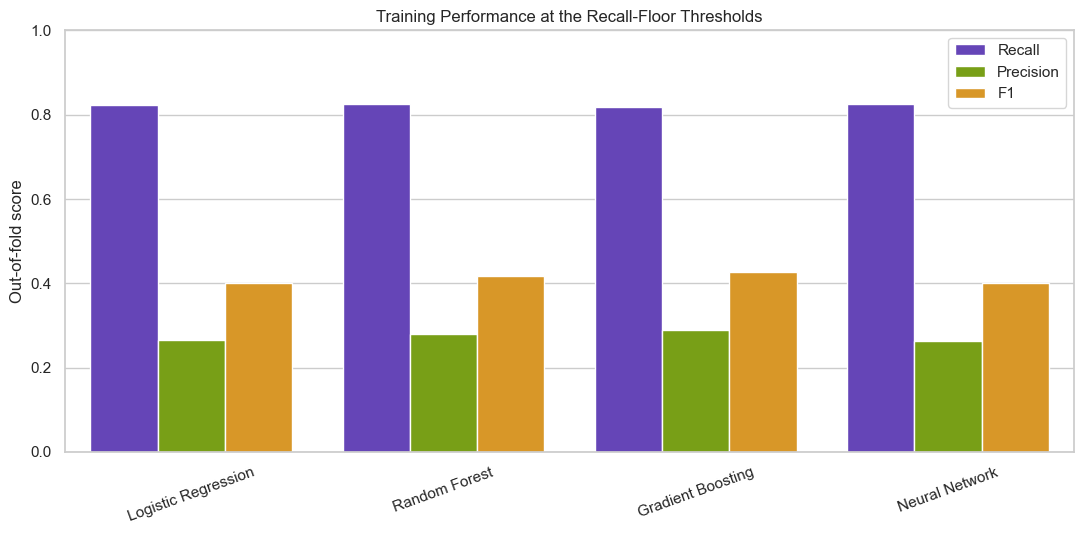

,Model,Threshold,Recall,Recall lower 95%,Precision,F1,Balanced accuracy,Accuracy,Share flagged
2,Logistic Regression,0.125,0.823,0.805,0.266,0.402,0.656,0.551,0.567
5,Random Forest,0.130,0.826,0.808,0.279,0.417,0.674,0.577,0.542
8,Gradient Boosting,0.130,0.819,0.801,0.290,0.428,0.684,0.599,0.517
11,Neural Network,0.115,0.826,0.809,0.264,0.400,0.655,0.547,0.573


,Model,Threshold,Recall,Precision,F1,Share flagged
1,Logistic Regression,0.235,0.556,0.362,0.439,0.281
4,Random Forest,0.225,0.600,0.364,0.453,0.302
7,Gradient Boosting,0.205,0.634,0.362,0.461,0.321
10,Neural Network,0.240,0.549,0.379,0.449,0.265


,Recall floor,Threshold,Recall,Precision,Share flagged,Implied cost ratio (FN:FP),Floor met
0,0.70,0.170,0.724,0.331,0.401,4.882,True
1,0.75,0.150,0.774,0.311,0.455,5.667,True
2,0.80,0.130,0.819,0.290,0.517,6.692,True
3,0.85,0.105,0.874,0.263,0.609,8.524,True
4,0.90,0.080,0.921,0.236,0.714,11.500,True


In [22]:
selected_threshold_results = threshold_comparison.loc[
    threshold_comparison["Threshold type"] == "Recall-floor (primary)"
].copy()

threshold_plot_data = selected_threshold_results.melt(
    id_vars=["Model", "Threshold"],
    value_vars=["Recall", "Precision", "F1"],
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(11, 5.5))
axis = sns.barplot(
    data=threshold_plot_data,
    x="Model",
    y="Score",
    hue="Metric",
    palette=[PURPLE, GREEN, ORANGE],
)

axis.set_title("Training Performance at the Recall-Floor Thresholds")
axis.set_xlabel("")
axis.set_ylabel("Out-of-fold score")
axis.set_ylim(0, 1)
axis.tick_params(axis="x", rotation=20)
axis.legend(title="")

plt.tight_layout()
plt.show()

display(
    selected_threshold_results[
        [
            "Model",
            "Threshold",
            "Recall",
            "Recall lower 95%",
            "Precision",
            "F1",
            "Balanced accuracy",
            "Accuracy",
            "Share flagged",
        ]
    ].round(
        {
            "Threshold": 3,
            "Recall": 3,
            "Recall lower 95%": 3,
            "Precision": 3,
            "F1": 3,
            "Balanced accuracy": 3,
            "Accuracy": 3,
            "Share flagged": 3,
        }
    )
)

# The F1-maximizing threshold, kept only as a reference point for how far the
# recall floor moves each model away from the balanced-metric cutoff.
f1_reference_results = threshold_comparison.loc[
    threshold_comparison["Threshold type"] == "F1 (secondary)",
    ["Model", "Threshold", "Recall", "Precision", "F1", "Share flagged"],
]

display(f1_reference_results.round(3))

# How the primary model's threshold, flagged share, and implied cost ratio
# move as the recall requirement is raised or lowered. Calibration was already
# checked, which is what licenses reading a threshold as a cost assumption.
primary_model = "Gradient Boosting"
primary_probabilities = out_of_fold_probabilities[primary_model].to_numpy()

sensitivity_rows = []
for target_recall in [0.70, 0.75, 0.80, 0.85, 0.90]:
    sensitivity_selected, _, sensitivity_met = select_threshold_by_recall_floor(
        y,
        primary_probabilities,
        candidate_thresholds,
        target_recall,
    )
    implied_cost_ratio = (
        1 - sensitivity_selected["Threshold"]
    ) / sensitivity_selected["Threshold"]
    sensitivity_rows.append(
        {
            "Recall floor": target_recall,
            "Threshold": sensitivity_selected["Threshold"],
            "Recall": sensitivity_selected["Recall"],
            "Precision": sensitivity_selected["Precision"],
            "Share flagged": sensitivity_selected["Share flagged"],
            "Implied cost ratio (FN:FP)": implied_cost_ratio,
            "Floor met": sensitivity_met,
        }
    )

threshold_sensitivity = pd.DataFrame(sensitivity_rows)
threshold_sensitivity.round(3)


At the 80% recall floor, thresholds range from 0.115 (neural network) to 0.130 (random forest and gradient boosting). All four models land at similar recall, between 0.819 and 0.826, with 95% lower bounds that clear 0.80 by a small but real margin (about 0.1 to 0.9 percentage points, rather than sitting exactly on the line). Precision at these cutoffs falls to about 0.26–0.29, and each model now flags a bit more than half the training cohort, from 51.7% for gradient boosting up to 57.3% for the neural network.

Gradient boosting is designated as the primary model, carrying its recall-floor threshold of 0.130 into Notebook 5. Although gradient boosting and random forest were effectively tied on PR-AUC, gradient boosting had higher ROC-AUC, slightly better calibration, and better precision at the 80% recall operating point. This decision is fixed before opening the test set. The other three models, and the F1-maximizing threshold shown alongside as a reference point, are pre-specified secondary comparisons — reported for context, not competing headline claims, regardless of which one happens to score best on the test set.

Moving from the F1 threshold to the recall floor is a tradeoff, not an improvement in what the model can do. Gradient boosting's balanced accuracy barely changes, 0.684 versus 0.692 at the old F1 threshold, which confirms this is the same model sliding to a different point on the same precision-recall curve rather than discriminating any better. Raw accuracy, however, drops substantially, to 0.599, well below the 0.817 achieved by predicting "no cavity" for everyone. That is the expected cost of deliberately flagging half the cohort to avoid missing cases, not a sign the model has gotten worse. Among the roughly half of participants the model does not flag, about 6.9% still have an untreated cavity — the residual risk that any screening rule at this recall leaves behind.

The threshold of 0.130 also has a direct cost interpretation, since the out-of-fold probabilities were already shown to be reasonably calibrated: it implies treating a missed cavity as about 6.7 times worse than an unnecessary referral. The sensitivity table above shows this is a dial, not a fixed fact. Requiring 90% recall would push the implied ratio to roughly 11.5:1 and flag over 70% of the cohort; requiring 70% recall would relax it to about 5:1 while flagging 40% of the cohort.

Even with the Wilson-interval margin built into the selection, hitting a recall target exactly is not guaranteed on new data. The leave-one-fold-out transfer check re-selects the threshold using only four folds and scores it on the fifth, which never influenced that selection. For gradient boosting, held-out recall averaged 0.823 (SD 0.034) across the five folds, but two of the five folds landed just under the 0.80 floor, at 0.796 and 0.798. That is a realistic preview of Notebook 5: test-set recall landing a point or two below 0.80 would be consistent with ordinary sampling variation given roughly 1,900 cavity cases, not a sign the rule failed, and it will be reported as such rather than retuned after the fact. The fold-level re-selection shown in the table above answers a narrower question, it shows the rule's own threshold barely moves at one-fifth the sample size (SD 0.005 to 0.019), but unlike the transfer check, it is not itself an out-of-sample estimate, since each fold took part in choosing the pooled threshold.

This is a modeling tradeoff rather than a clinical recommendation. The project predicts NHANES examination outcomes and does not establish a threshold suitable for diagnosis or treatment decisions.


## Inspecting Neural-Network Training

The neural network is the only model here that learns through repeated training iterations. Its loss curve shows whether the optimization process stabilized, while the internal validation curve shows when early stopping decided that further training was no longer helping.

There is an important limitation: `MLPClassifier` uses ordinary accuracy for its internal early-stopping score and does not provide a parameter for replacing that score with PR-AUC. With only about 18% cavity cases, accuracy changes very little across many probability patterns. The internal curve is therefore only an optimization diagnostic; five-fold PR-AUC remains the metric used to compare the neural network with the other models.

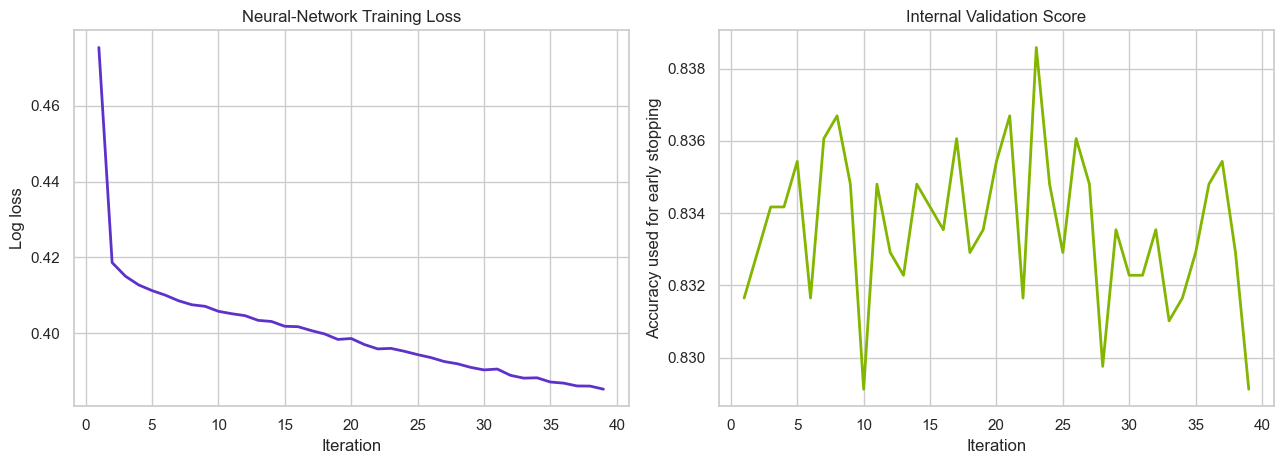

,Training detail,Result
0,Iterations completed,39
1,Final training loss,0.3853
2,Best internal validation score,0.8386
3,No-cavity accuracy benchmark,0.8169
4,Margin above no-cavity benchmark,0.0217
5,Stopped before maximum iterations,True


In [23]:
fitted_neural_network = best_models["Neural Network"].named_steps["model"]

neural_summary = pd.DataFrame(
    {
        "Training detail": [
            "Iterations completed",
            "Final training loss",
            "Best internal validation score",
            "No-cavity accuracy benchmark",
            "Margin above no-cavity benchmark",
            "Stopped before maximum iterations",
        ],
        "Result": [
            fitted_neural_network.n_iter_,
            round(fitted_neural_network.loss_, 4),
            round(fitted_neural_network.best_validation_score_, 4),
            round(1 - y.mean(), 4),
            round(
                fitted_neural_network.best_validation_score_ - (1 - y.mean()),
                4,
            ),
            fitted_neural_network.n_iter_ < fitted_neural_network.max_iter,
        ],
    }
)

figure, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(
    range(1, len(fitted_neural_network.loss_curve_) + 1),
    fitted_neural_network.loss_curve_,
    color=PURPLE,
    linewidth=2,
)
axes[0].set_title("Neural-Network Training Loss")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Log loss")

axes[1].plot(
    range(1, len(fitted_neural_network.validation_scores_) + 1),
    fitted_neural_network.validation_scores_,
    color=GREEN,
    linewidth=2,
)
axes[1].set_title("Internal Validation Score")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Accuracy used for early stopping")

plt.tight_layout()
plt.show()

neural_summary

The selected neural network stopped after 39 iterations rather than continuing to the maximum of 400. Training loss continued to decline gradually, but the accuracy-based internal validation score fluctuated within a narrow range and peaked only modestly above the approximately 0.817 no-cavity benchmark.

That narrow curve is partly a consequence of the metric rather than proof that every later iteration was equally useful for cavity detection. Early stopping still provides protection against excessive training, but it may stop at a different point than a PR-AUC-based rule would choose.

These curves help verify that optimization behaved normally, but they do not replace cross-validation or the final test-set evaluation.

## Saving the Final Training Artifacts

Each search automatically refitted its selected pipeline on all 10,572 training participants. This section saves those complete pipelines, including preprocessing, so Notebook 5 can apply exactly the same transformations to the untouched test data.

The saved metadata records the predictors, train/test split seed, cross-validation designs, selected hyperparameters, the recall-floor threshold rule and the resulting thresholds, the pre-committed primary model, software versions, and a fingerprint of the training file. Supporting CSV tables preserve the development results, out-of-fold probabilities, calibration check, repeated comparison, tuning gains, threshold stability, and the threshold transfer check.


In [24]:
model_filenames = {
    "Logistic Regression": "logistic_regression.joblib",
    "Random Forest": "random_forest.joblib",
    "Gradient Boosting": "gradient_boosting.joblib",
    "Neural Network": "neural_network.joblib",
}

saved_model_paths = {}

for model_name, model in best_models.items():
    model_path = MODEL_FOLDER / model_filenames[model_name]
    joblib.dump(model, model_path)
    saved_model_paths[model_name] = model_path


# Built from the explicit "Recall-floor (primary)" label rather than a filter
# that could also match other rows, with a length check so a mismatch raises
# immediately instead of silently saving the wrong cutoff.
primary_threshold_rows = threshold_comparison.loc[
    threshold_comparison["Threshold type"] == "Recall-floor (primary)"
]
assert len(primary_threshold_rows) == len(best_models)
selected_thresholds = {
    row["Model"]: float(row["Threshold"])
    for _, row in primary_threshold_rows.iterrows()
}

secondary_threshold_rows = threshold_comparison.loc[
    threshold_comparison["Threshold type"] == "F1 (secondary)"
]
secondary_f1_thresholds = {
    row["Model"]: float(row["Threshold"])
    for _, row in secondary_threshold_rows.iterrows()
}

# The primary model was designated in "Comparing the Tuned Models" for its
# PR-AUC lead and confirmed here as the recall-floor operating point Notebook
# 5 will report; primary_model is defined again for clarity in case this cell
# is ever run out of order.
primary_model = "Gradient Boosting"
primary_threshold = selected_thresholds[primary_model]

# The save step is the last place a degraded fallback threshold could still
# be caught before it ships to Notebook 5.
assert all(floor_met_by_model.values()), (
    "Refusing to save: at least one model's recall-floor threshold fell back "
    "to flag-everyone because it could not clear the target with confidence."
)


def make_json_safe(value):
    """Convert NumPy values and tuples into standard JSON-compatible values."""
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, tuple):
        return list(value)
    return value


metadata = {
    "training_file": TRAINING_PATH.name,
    "training_file_sha256": hashlib.sha256(TRAINING_PATH.read_bytes()).hexdigest(),
    "training_rows": len(training_data),
    "target": "has_cavity",
    "features": feature_columns,
    "cross_validation": {
        "type": "StratifiedKFold",
        "n_splits": 5,
        "shuffle": True,
        "random_state": RANDOM_STATE,
    },
    "train_test_split": {
        "source_notebook": "3) Exploring the Data.ipynb",
        "test_size": 0.20,
        "stratified_by": "has_cavity",
        "random_state": RANDOM_STATE,
    },
    "repeated_cross_validation": {
        "type": "RepeatedStratifiedKFold",
        "n_splits": 5,
        "n_repeats": 3,
        "random_state": RANDOM_STATE,
        "purpose": "paired stability comparison of the top two models",
    },
    "primary_selection_metric": "average_precision",
    "primary_model": primary_model,
    "primary_threshold": primary_threshold,
    "threshold_selection": {
        "rule": "highest_threshold_with_oof_recall_95pct_lower_bound_ge_target",
        "target_recall": TARGET_RECALL,
        "confidence_method": "wilson_score_interval",
        "confidence_level": 0.95,
        "threshold_grid": {"min": 0.05, "max": 0.95, "step": 0.005},
        "floor_met": {
            model_name: bool(met) for model_name, met in floor_met_by_model.items()
        },
        "primary_thresholds": selected_thresholds,
        "secondary_f1_thresholds": secondary_f1_thresholds,
    },
    "best_parameters": {
        model_name: {
            parameter.replace("model__", ""): make_json_safe(value)
            for parameter, value in search.best_params_.items()
        }
        for model_name, search in model_searches.items()
    },
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "scikit_learn_version": sklearn.__version__,
}

metadata_path = MODEL_FOLDER / "model_metadata.json"
metadata_path.write_text(json.dumps(metadata, indent=2))

development_table_path = TABLE_FOLDER / "model_development_cv_results.csv"
tuning_gain_path = TABLE_FOLDER / "model_tuning_gains.csv"
threshold_table_path = TABLE_FOLDER / "model_thresholds.csv"
threshold_stability_path = TABLE_FOLDER / "model_threshold_stability.csv"
threshold_transfer_path = TABLE_FOLDER / "model_threshold_transfer_check.csv"
out_of_fold_path = TABLE_FOLDER / "model_out_of_fold_predictions.csv"
calibration_path = TABLE_FOLDER / "model_calibration_results.csv"
repeated_cv_path = TABLE_FOLDER / "top_model_repeated_cv_results.csv"

development_comparison.to_csv(development_table_path, index=False)
tuning_gain.to_csv(tuning_gain_path, index=False)
threshold_comparison.to_csv(threshold_table_path, index=False)
threshold_stability.to_csv(threshold_stability_path, index=False)
transfer_check_results.to_csv(threshold_transfer_path, index=False)
out_of_fold_probabilities.to_csv(out_of_fold_path, index=False)
calibration_summary.to_csv(calibration_path, index=False)
repeated_fold_results.to_csv(repeated_cv_path, index=False)


# Reload each saved pipeline and verify that it can produce probabilities with
# the original 13-column predictor structure.
for model_name, model_path in saved_model_paths.items():
    reloaded_model = joblib.load(model_path)
    test_probabilities = reloaded_model.predict_proba(X.head(5))

    assert test_probabilities.shape == (5, 2)
    assert np.isfinite(test_probabilities).all()


saved_files = pd.DataFrame(
    {
        "Artifact": [
            *saved_model_paths.keys(),
            "Model metadata",
            "Cross-validation results",
            "Tuning gains",
            "Threshold results",
            "Threshold stability",
            "Threshold transfer check",
            "Out-of-fold predictions",
            "Calibration results",
            "Repeated cross-validation",
        ],
        "Saved file": [
            *[path.name for path in saved_model_paths.values()],
            metadata_path.name,
            development_table_path.name,
            tuning_gain_path.name,
            threshold_table_path.name,
            threshold_stability_path.name,
            threshold_transfer_path.name,
            out_of_fold_path.name,
            calibration_path.name,
            repeated_cv_path.name,
        ],
    }
)

print(f"Primary model: {primary_model}  |  primary threshold: {primary_threshold:.3f}")
print("Every saved model reloaded and produced valid probabilities.")
saved_files


Primary model: Gradient Boosting  |  primary threshold: 0.130
Every saved model reloaded and produced valid probabilities.


,Artifact,Saved file
0,Logistic Regression,logistic_regression.joblib
1,Random Forest,random_forest.joblib
2,Gradient Boosting,gradient_boosting.joblib
3,Neural Network,neural_network.joblib
4,Model metadata,model_metadata.json
5,Cross-validation results,model_development_cv_results.csv
6,Tuning gains,model_tuning_gains.csv
7,Threshold results,model_thresholds.csv
8,Threshold stability,model_threshold_stability.csv
9,Threshold transfer check,model_threshold_transfer_check.csv


The `.joblib` files contain both preprocessing and the fitted model, so later notebooks do not need to recreate scaling or income imputation manually. The model files are excluded from Git because they can be reproduced by rerunning this notebook, while the code, settings, and result tables document exactly how they were created.

## Conclusion

This notebook completed the full model-development stage:

- The test set remained untouched.
- NHANES survey weights and clustering were documented as limits on population interpretation.
- All preprocessing occurred inside leakage-safe pipelines.
- A dummy baseline and four machine-learning models were compared with the same five stratified folds.
- Logistic regression, random forest, gradient boosting, and a neural network were tuned using PR-AUC.
- The top two models were compared with paired repeated cross-validation rather than independent-looking error bars.
- Out-of-fold probabilities were checked for calibration and saved for later analysis.
- Classification thresholds were selected to almost always guarantee an 80% recall floor, with a statistical margin so the floor holds up beyond this sample, rather than by maximizing F1.
- A non-circular, leave-one-fold-out check estimated how well that threshold is likely to transfer to new data.
- Gradient boosting and its recall-floor threshold were pre-committed as the primary result for Notebook 5, before the test set is opened.
- The selected pipelines, supporting tables, and expanded reproducibility metadata were saved for later notebooks.

The cross-validation results indicate which models appear most promising, but they are not the final project results. Notebook 5 will load the saved pipelines and evaluate them once on `test_data.csv`, without additional tuning.
